### SVM の実装：

#### https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.svm import SVC
#from mlxtend.plotting import plot_decision_regions
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve, auc

In [4]:
df = pd.read_csv('/Users/yoshizawakazuki/Desktop/Datasets/Logit_data.csv')
df

/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_76597/3983127250.py:1: DtypeWarning: Columns (39,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/yoshizawakazuki/Desktop/Datasets/Logit_data.csv')


,Unnamed: 0,key,y,x,label,pred,class_0,class_1,class_2,class_3,...,ignore_error_flag,error,combination,difference,type,ratio,ratio_type,shape,difference_shape,Target
0,0,frankfurt_000001_066832,0,0,255,2,-1.434775,-2.083891,5.882963,-0.671847,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,frankfurt_000001_066832,0,1,255,2,-1.434775,-2.083891,5.882963,-0.671847,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2,frankfurt_000001_066832,0,2,255,2,-1.464877,-2.085818,5.967637,-0.636951,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
3,3,frankfurt_000001_066832,0,3,255,2,-1.525080,-2.089673,6.136985,-0.567160,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
4,4,frankfurt_000001_066832,0,4,255,2,-1.585284,-2.093527,6.306334,-0.497369,...,True,False,2-255,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2097147,2097147,frankfurt_000001_066832,1023,2043,255,0,3.679024,1.801963,3.178625,0.278655,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2097148,2097148,frankfurt_000001_066832,1023,2044,255,0,3.551764,1.768597,3.167632,0.275143,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2097149,2097149,frankfurt_000001_066832,1023,2045,255,0,3.424504,1.735231,3.156638,0.271630,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1
2097150,2097150,frankfurt_000001_066832,1023,2046,255,0,3.360874,1.718548,3.151142,0.269874,...,True,False,0-255,NaN,NaN,NaN,NaN,NaN,NaN,1


In [5]:
# Target: Correct or Incorrect
df['Target']= np.where(df['label']!=df['pred'],1,0)

data = df[df['label']!=255]
data


,Unnamed: 0,key,y,x,label,pred,class_0,class_1,class_2,class_3,...,ignore_error_flag,error,combination,difference,type,ratio,ratio_type,shape,difference_shape,Target
10258,10258,frankfurt_000001_066832,5,18,2,2,-0.534489,-0.812796,6.592903,-0.047219,...,False,False,2-2,2.757286,Correct,0.581780,Correct,NaN,NaN,0
10259,10259,frankfurt_000001_066832,5,19,2,2,-0.477625,-0.741803,6.600158,-0.059776,...,False,False,2-2,2.769392,Correct,0.580405,Correct,NaN,NaN,0
10260,10260,frankfurt_000001_066832,5,20,2,2,-0.420761,-0.670811,6.607413,-0.072333,...,False,False,2-2,2.781497,Correct,0.579034,Correct,NaN,NaN,0
10261,10261,frankfurt_000001_066832,5,21,2,2,-0.363896,-0.599819,6.614668,-0.084890,...,False,False,2-2,2.793603,Correct,0.577665,Correct,NaN,NaN,0
10262,10262,frankfurt_000001_066832,5,22,2,2,-0.320220,-0.548411,6.621589,-0.101053,...,False,False,2-2,2.804602,Correct,0.576446,Correct,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003257,2003257,frankfurt_000001_066832,978,313,0,0,5.357340,0.685261,0.429156,-0.950583,...,False,False,0-0,4.672080,Correct,0.127911,Correct,NaN,NaN,0
2003258,2003258,frankfurt_000001_066832,978,314,0,0,5.361503,0.679614,0.457499,-0.952495,...,False,False,0-0,4.681889,Correct,0.126758,Correct,NaN,NaN,0
2003259,2003259,frankfurt_000001_066832,978,315,0,0,5.383006,0.671272,0.478162,-0.952101,...,False,False,0-0,4.711734,Correct,0.124702,Correct,NaN,NaN,0
2003260,2003260,frankfurt_000001_066832,978,316,0,0,5.404508,0.662930,0.498825,-0.951707,...,False,False,0-0,4.741578,Correct,0.122662,Correct,NaN,NaN,0


In [6]:
# Data Preparation:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
X = data[[col for col in data.columns if col.startswith('class_')]]
y = data['Target']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
# Train vs Test = 7:3 , Error vs Correct それぞれ 1.2percentにする
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

#### サンプル数が多いものに関してはLinearSVCを試すべき

In [ ]:
# 標準化とSVCをセットにするのが一般的　
from sklearn.pipeline import Pipeline
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

# 学習
clf.fit(X_train, y_train)

# 精度確認
print(f"Accuracy: {clf.score(X_test, y_test)}")

#### Linear SVC; Probability出力メソッドがないので、SVCを使うか、CalibratedClassifierCVでラップする必要がある

In [ ]:
# Lineαr SVC
# 大規模データや特徴量が多い場合に適した設定例
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_svc', LinearSVC(
        C=1.0, 
        loss='squared_hinge', # 'squared_hinge' (デフォルト): 誤差を2乗して計算します。'hinge': 標準的なSVMの損失関数です。
        class_weight='balanced',
        dual='auto', # 自動で最適な方を選択（最新版）
        max_iter=2000,
        random_state=42
    ))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc',
                 LinearSVC(class_weight='balanced', max_iter=2000,
                           random_state=42))])

In [12]:
predictions = clf.predict(X_test)

##### class_weight=balancedにするとAccuracyが落ちているが、不均衡データセットを使っている以上、こちらの方が正確なのか

In [13]:
accuracy = np.mean(predictions == y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8563481932872293


In [15]:
score = clf.score(X_test, y_test)
print(f"Score: {score}")

Score: 0.8563481932872293


# SGDClassifier

#### class sklearn.linear_model.SGDClassifier(loss='hinge', *, penalty='l2', alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=0.001, shuffle=True, verbose=0, epsilon=0.1, n_jobs=None, random_state=None, learning_rate='optimal', eta0=0.01, power_t=0.5, early_stopping=False, validation_fraction=0.1, n_iter_no_change=5, class_weight=None, warm_start=False, average=False)

In [ ]:
#### ２値分類問題に適しているのがSVMの特徴：また、基本的には線形モデルである
from sklearn.linear_model import SGDClassifier
model = Pipeline([
    ('scaler', StandardScaler()),
    ('SGD', SGDClassifier(
        loss='log_loss', # hinge or log_loss など
        alpha=0.01,
        max_iter=2000,
        tol=1e-3,
        random_state=42,
        n_jobs=-1,
        early_stopping=True,
        class_weight='balanced',

    ))])

model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)

model.coef_

In [22]:
print(f"SGD Classifier Accuracy: {accuracy}")

SGD Classifier Accuracy: 0.8524816618435203


In [46]:
predictions = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

In [49]:

recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)


roc_auc = roc_auc_score(y_test, probs)
precision_points, recall_points, _ = precision_recall_curve(y_test, probs)
pr_auc = auc(recall_points, precision_points)


In [45]:
predictions

array([0, 1, 1, ..., 0, 0, 0])

In [52]:
print("Details")
print("Classes:")
print(model.classes_)
print("Number of features in training data:")
print(model.n_features_in_)
print("probs:")
print(probs)    

print(f"Accuracy: {model.score(X_test, y_test)}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")
print(f"PR AUC: {pr_auc}")

Details
Classes:
[0 1]
Number of features in training data:
19
probs:
[0.37591648 0.66821362 0.94920829 ... 0.38632324 0.15932887 0.23085702]
Accuracy: 0.8524816618435203
Recall: 0.8196343582382715
F1 Score: 0.39136080800793577
ROC AUC: 0.9108189677762183
PR AUC: 0.3168946879920934


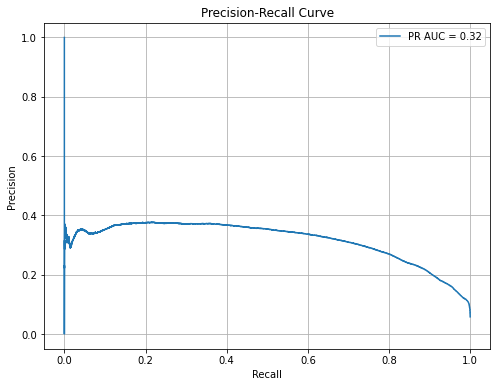

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

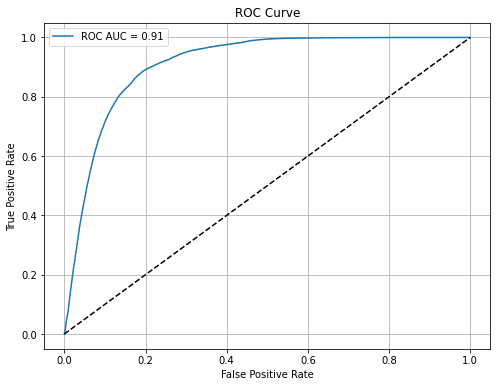

In [54]:
# AUC ROC曲線のプロット
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # 対角線
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()  

##### 各Featureの寄与率を計算して可視化するFlow

In [32]:
sgd_model = model.named_steps['SGD']
feature_names = X_train.columns
coefficients = sgd_model.coef_[0] # 2クラス分類なら[0]でOK


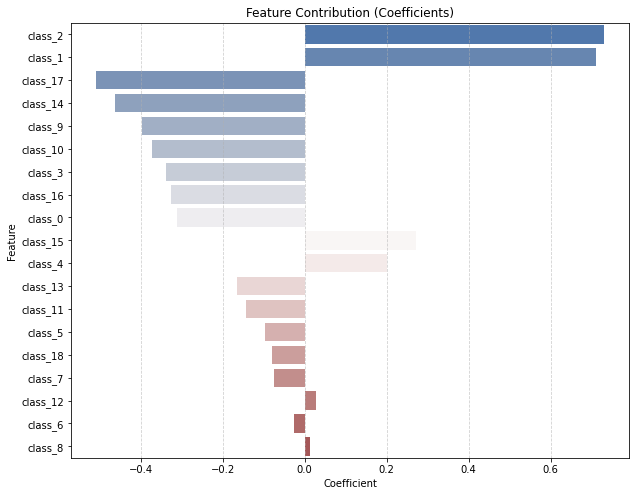

In [33]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'AbsCoefficient': abs(coefficients) # 寄与の大きさを測るための絶対値
}).sort_values(by='AbsCoefficient', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='vlag')
plt.title('Feature Contribution (Coefficients)')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

#### 具体的な寄与率などを可視化する

In [34]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

{'importances_mean': array([-0.0129814 ,  0.05936492, -0.0041557 ,  0.01674717,  0.00038993,
         0.00456574,  0.00045725,  0.00119537, -0.00068916,  0.00690905,
         0.01465085,  0.00339311,  0.00075123, -0.00026819,  0.00044698,
         0.00865587, -0.00071364, -0.01150211, -0.00134137]),
 'importances_std': array([1.16344161e-04, 2.01546712e-04, 3.11671210e-04, 1.66489153e-04,
        1.20774204e-04, 1.12832278e-04, 4.03831348e-05, 5.14033729e-05,
        4.03505890e-05, 1.18585915e-04, 2.32291322e-04, 4.98343227e-05,
        5.17701013e-05, 9.54287171e-05, 2.25532098e-04, 9.23179750e-05,
        1.71213560e-04, 2.54819606e-04, 8.56903783e-05]),
 'importances': array([[-0.01304654, -0.01291758, -0.01300501, -0.01302031, -0.01305091,
         -0.0129307 , -0.01291321, -0.012946  , -0.01275584, -0.01322795],
        [ 0.05932689,  0.0594012 ,  0.05904274,  0.05933563,  0.05960884,
          0.05910613,  0.05936623,  0.0597378 ,  0.0592329 ,  0.05949082],
        [-0.00407636,

#### 負の値はノイズとして捉えても良いか、また、０に近いような変数は除いても良い

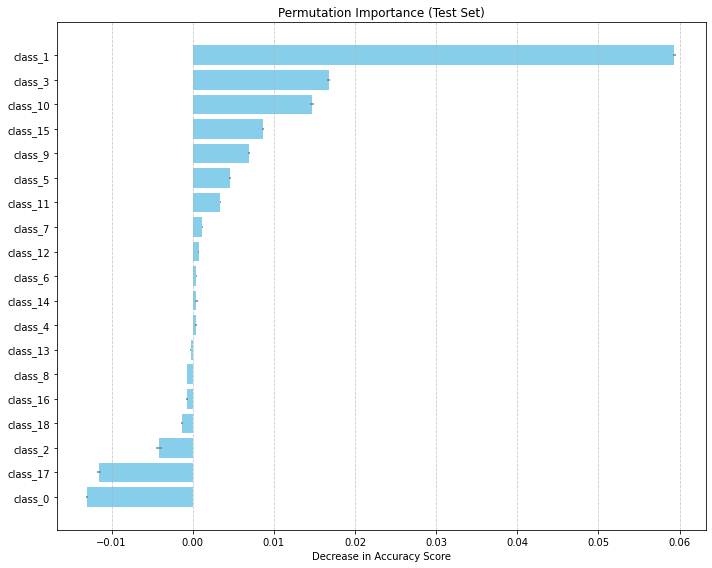

In [36]:
feature_names = X_test.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)


plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance_Mean'], 
         xerr=importance_df['Importance_Std'], align='center', color='skyblue', ecolor='gray')

plt.gca().invert_yaxis() 
plt.xlabel('Decrease in Accuracy Score') 
plt.title('Permutation Importance (Test Set)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
for i in range(19):
    print(f"Class {i} mean:", X_test[f'class_{i}'].mean())

Class 0 mean: 2.633748541266134
Class 1 mean: 0.5798354924266206
Class 2 mean: 2.0538410307922383
Class 3 mean: -0.475762303325444
Class 4 mean: -0.2802182406397543
Class 5 mean: 0.012809553020071232
Class 6 mean: -0.7515595054593972
Class 7 mean: -0.48302725226000204
Class 8 mean: 1.0861728276452745
Class 9 mean: -0.17179667930859985
Class 10 mean: -0.4348145273999598
Class 11 mean: 0.1281581793021836
Class 12 mean: -0.7898269757391071
Class 13 mean: 0.22269284900824435
Class 14 mean: -0.5880645792039793
Class 15 mean: -0.622544793253396
Class 16 mean: -0.5282070484342999
Class 17 mean: -0.8272172463001055
Class 18 mean: -0.4699877625966756
